# Simple Linear Regression: Predicting Height from Weight

## Overview
This notebook demonstrates **Simple Linear Regression**, one of the most fundamental supervised machine learning algorithms used to model the relationship between two continuous variables.

**Definition:** Simple Linear Regression models the relationship between a single independent variable (predictor) and a dependent variable (target) by fitting a straight line of the form:

$$y = mx + c$$

where:
- **y** = dependent variable (the value we want to predict)
- **x** = independent variable (the predictor)
- **m** = slope (coefficient) — the change in y for a unit change in x
- **c** = intercept — the value of y when x = 0

**Dataset:** We use a `height-weight.csv` dataset containing two columns — `Weight` and `Height` — and build a model to predict a person's **Height** based on their **Weight**.

**Workflow:**
1. Load and explore the data
2. Visualize relationships (scatter plot, correlation, pairplot)
3. Split data into independent/dependent features
4. Perform train-test split
5. Standardize the features
6. Train a Linear Regression model
7. Evaluate the model using performance metrics
8. Fit an OLS (Ordinary Least Squares) regression for statistical insights
9. Predict on new, unseen data


## 1. Import Required Libraries

We begin by importing the core Python libraries used for data handling (`pandas`), numerical computation (`numpy`), and visualization (`matplotlib`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## 2. Load the Dataset

**Definition:** Loading data is the first step in any ML pipeline — we read the raw data into a `pandas` DataFrame so it can be inspected and manipulated. Here we load the `height-weight.csv` file and preview the first five rows.

In [5]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


## 3. Exploratory Data Analysis (EDA)

Before modeling, we explore the data visually and statistically to understand the relationship between `Weight` and `Height`.

### 3.1 Scatter Plot

**Definition:** A **scatter plot** displays individual data points on an X-Y axis, allowing us to visually inspect whether a linear relationship exists between two variables. Here, `Weight` is plotted against `Height`.

Text(0, 0.5, 'Height')

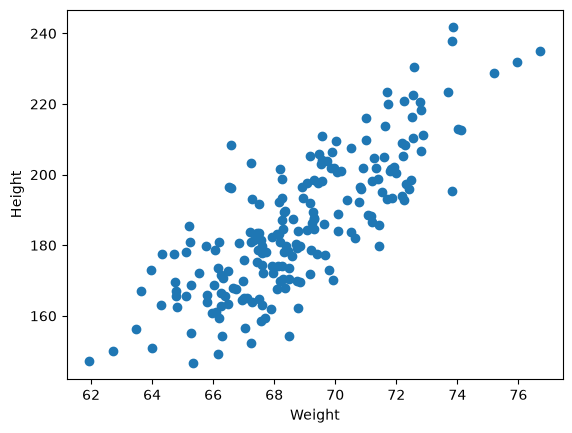

In [6]:
plt.scatter(df['Weight'], df['Height'])

plt.xlabel("Weight")
plt.ylabel("Height")

### 3.2 Correlation

**Definition:** **Correlation** measures the strength and direction of the linear relationship between two variables, ranging from -1 to +1. A value close to +1 indicates a strong positive linear relationship — as one variable increases, so does the other.

In [7]:
df.corr()

,Weight,Height
Weight,1.000,0.802
Height,0.802,1.000


### 3.3 Pairplot Visualization (Seaborn)

**Definition:** A **pairplot** (from the `seaborn` library) plots pairwise relationships and distributions across all numeric columns in a dataset, giving a quick visual summary of trends and spread.

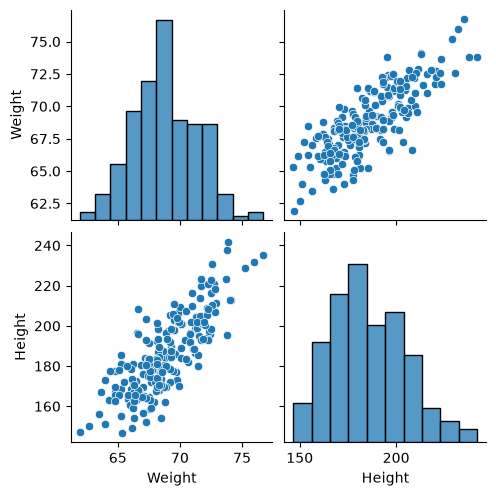

In [8]:
import seaborn as sns
sns.pairplot(df)

## 4. Independent and Dependent Features

**Definition:**
- **Independent Feature (X):** The predictor variable used as input to the model — here, `Weight`.
- **Dependent Feature (y):** The target variable we want to predict — here, `Height`.

By convention, `X` should be a DataFrame (2D) and `y` a Series (1D).

In [10]:
df.head()

,Weight,Height
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [11]:
X = df[['Weight']]     ## Independent features should be dataframe or 2D array
y = df['Height']     ## This variable can be in series or 1D array

print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


## 5. Train-Test Split

**Definition:** **Train-test splitting** divides the dataset into a **training set** (used to fit the model) and a **testing set** (used to evaluate the model's performance on unseen data), helping detect overfitting.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, random_state=42)

## 6. Feature Scaling — Standardization

**Definition:** **Standardization** rescales features so they have a mean of 0 and a standard deviation of 1 (Z-score normalization):

$$z = \frac{x - \mu}{\sigma}$$

This ensures features are on a comparable scale, which can improve model stability and convergence.

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [16]:
X_test = scaler.transform(X_test)

In [17]:
X_test

array([[-1.42055352],
       [-0.45553478],
       [-0.0843236 ],
       [-0.09378051],
       [ 0.17778201],
       [ 1.84984142],
       [ 0.02201958],
       [-0.13632617],
       [-1.05882369],
       [ 0.48315797],
       [-0.21560155],
       [-0.93014372],
       [-1.42016441],
       [-0.88801114],
       [ 0.42615503],
       [-0.22638391],
       [-0.18549779],
       [ 0.76534836],
       [ 1.90363743],
       [-0.28232922],
       [ 1.30522103],
       [ 1.36625968],
       [-1.00644864],
       [-1.56772603],
       [-1.35878671],
       [ 0.97877096],
       [-1.09911678],
       [ 1.49873401],
       [ 0.79000337],
       [ 0.99423923],
       [-2.05457325],
       [ 0.30576646],
       [-0.89300308],
       [ 0.92143914],
       [-0.5190012 ],
       [ 0.47212724],
       [ 0.82559594],
       [-0.16933474],
       [-0.60135434],
       [ 1.13374771],
       [-1.07260452],
       [ 2.71223015],
       [-1.15723702],
       [-0.36103187],
       [-0.72131229],
       [ 1

## 7. Model Building — Linear Regression

**Definition:** We now fit a **Linear Regression** model using `scikit-learn`. The model learns the optimal **slope (coefficient)** and **intercept** that minimize the error between predicted and actual values.

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
regression = LinearRegression(n_jobs = -1)

In [20]:
regression.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[15.47]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,185.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[12.25]


In [21]:
print("Coefficient or Slope : ", regression.coef_ )       ## This is m , y = mx + c
print("Intercept ", regression.intercept_ )  

Coefficient or Slope :  [15.46822944]
Intercept  185.69354850266666


### 7.1 Best Fit Line Visualization

**Definition:** The **best fit line** is the straight line that minimizes the sum of squared differences between the actual data points and the predicted values — visualized here in red over the training data.

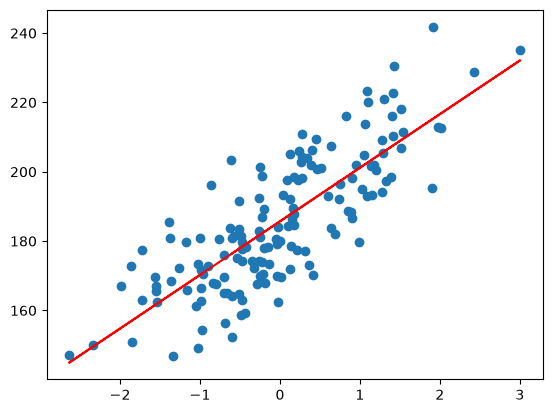

In [22]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train),color='red')

## 8. Prediction on Test Data

Using the trained model, we predict `Height` values for the test set (`X_test`) to evaluate generalization performance.

In [23]:
y_pred = regression.predict(X_test)   ## y_pred = 187.02 + 16.97['Weight]

## 9. Model Evaluation Metrics

**Definitions:**
- **MSE (Mean Squared Error):** Average of the squared differences between actual and predicted values — penalizes larger errors more heavily.
- **MAE (Mean Absolute Error):** Average of the absolute differences between actual and predicted values — robust to outliers.
- **RMSE (Root Mean Squared Error):** Square root of MSE, expressed in the same units as the target variable, making it more interpretable.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [25]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

134.28980614353662
8.89259994431111
11.588347860827126


### 9.1 R² Score (Coefficient of Determination)

**Definition:** **R²** measures the proportion of variance in the dependent variable explained by the independent variable(s). It ranges from 0 to 1 (or can be negative for poor fits), where values closer to 1 indicate a better fit.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

In [26]:
from sklearn.metrics import r2_score

In [27]:
score = r2_score(y_test, y_pred)
print(score)

0.6463890986954772


### 9.2 Adjusted R² Score

**Definition:** **Adjusted R²** modifies R² to account for the number of predictors in the model, penalizing the addition of variables that don't improve the model. It is especially useful when comparing models with a different number of features.

$$Adjusted\ R^2 = 1 - \frac{(1-R^2)(n-1)}{n-k-1}$$

where *n* = number of observations, *k* = number of predictors.

In [28]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6390222049182996

## 10. OLS Linear Regression (Statsmodels)

**Definition:** **OLS (Ordinary Least Squares)** is the statistical method underlying linear regression, minimizing the sum of squared residuals. Using the `statsmodels` library gives us a detailed statistical summary — including coefficients, p-values, confidence intervals, and R² — useful for statistical inference beyond just prediction.

In [29]:
!pip install statsmodels

import statsmodels.api as sm

In [30]:
model = sm.OLS(y_train, X_train).fit()

In [31]:
prediction = model.predict(X_test)
print(prediction)

[-21.97344777  -7.04631646  -1.30433682  -1.45061851   2.74997292
  28.61377148   0.3406039   -2.10872453 -16.3781277    7.47359838
  -3.33497429 -14.38767644 -21.96742888 -13.7359601    6.59186373
  -3.50175825  -2.86932234  11.83858408  29.4459005   -4.36713315
  20.18945834  21.1336182  -15.56797853 -24.24994589 -21.01802462
  15.13985371 -17.00139047  23.18276148  12.21995337  15.37912051
 -31.78061047   4.72966582 -13.81317649  14.25303207  -8.02802969
   7.30297253  12.77050741  -2.61930859  -9.30188684  17.53706963
 -16.59129283  41.95339828 -17.90040772  -5.58452376 -11.15742392
  20.4039917   -2.02287449  -5.33176499  -8.30690388 -13.24253561]


In [32]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):              0.000
Method:                 Least Squares   F-statistic:                              1.030
Date:                Mon, 27 Jul 2026   Prob (F-statistic):                       0.312
Time:                        02:33:57   Log-Likelihood:                         -996.75
No. Observations:                 150   AIC:                                      1995.
Df Residuals:                     149   BIC:                                      1999.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

## 11. Prediction on New Data

Finally, we use the trained `scikit-learn` regression model to predict the **Height** for a new, unseen **Weight** value, after applying the same standardization transform used during training.

In [33]:
regression.predict(scaler.transform([[72]]))

h:\mlCode\python\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([204.35725598])